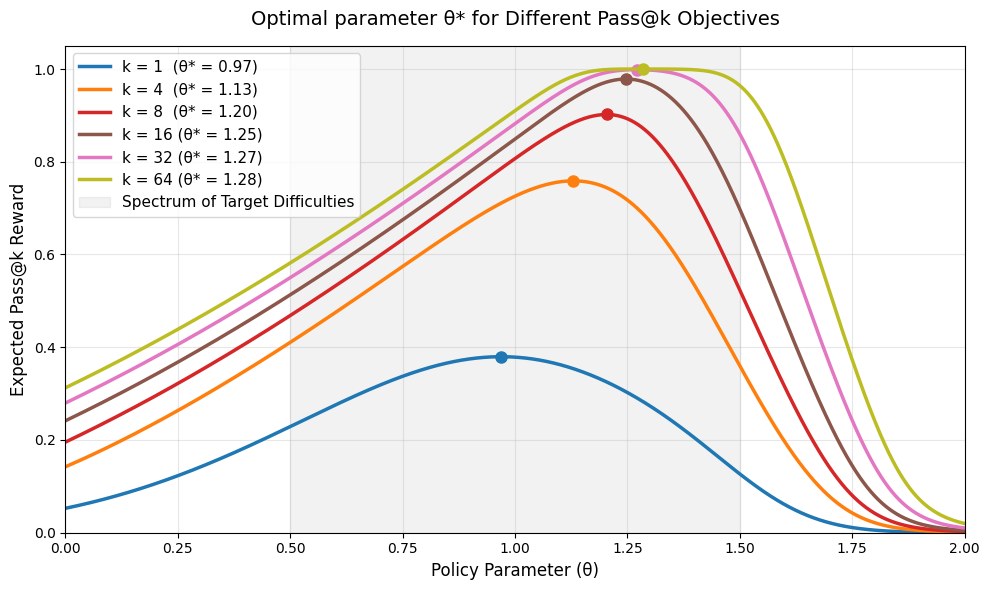

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# =====================================================================
# 1. EMPIRICAL SAMPLING FOR THE CONTINUOUS SPECTRUM
# =====================================================================

SIGMA = 0.2
THETA_INIT = 0.2
# State X has shape (n, X_DIM): col 0 is difficulty u ~ U(0.5,1.5); extra cols are random covariates.
# Reward / Z / P_success depend only on u (scalar policy θ multiplies u).
X_DIM = 1  # change here; re-run nets cell so in_features=X_DIM matches

def sample_data(n_problems, n_generations, sigma=SIGMA, theta_init=THETA_INIT):
    if X_DIM < 1:
        raise ValueError("X_DIM must be >= 1")
    x0 = np.random.uniform(0.5, 1.5, n_problems)
    if X_DIM == 1:
        X = x0.reshape(-1, 1)
    else:
        extras = np.random.standard_normal((n_problems, X_DIM - 1))
        X = np.column_stack([x0, extras])
    W = 0.07 - 0.04 * x0
    Z = np.random.normal(loc=theta_init * x0[:, None], scale=sigma, size=(n_problems, n_generations))
    X_col = x0[:, np.newaxis]
    W_col = W[:, np.newaxis]
    tolerance = np.sqrt(W_col)
    Y = (np.abs(Z - X_col**2) <= tolerance).astype(float)

    mu = theta_init * x0
    L = x0**2 - np.sqrt(W)
    U = x0**2 + np.sqrt(W)
    cdf_upper = norm.cdf(U, loc=mu, scale=sigma)
    cdf_lower = norm.cdf(L, loc=mu, scale=sigma)
    P_success = cdf_upper - cdf_lower

    score = ((Z - theta_init * x0[:, None]) * x0[:, None]) / sigma**2
    return X, Z, Y, P_success, score


def compute_analytical_curves(thetas, k_values, sigma=0.2):
    """
    Computes the EXACT expected Pass@k using the closed-form Normal CDF.
    No Monte Carlo sampling required. Averages only over task difficulty u in [0.5, 1.5];
    extra state dimensions in ``sample_data`` do not affect P(success|u) under this model.
    """
    X = np.linspace(0.5, 1.5, 1000) 
    W = 0.07 - 0.04 * X
    
    expected_rewards = {k: np.zeros(len(thetas)) for k in k_values}
    
    # Calculate the fixed target bounds for all X
    L = X**2 - np.sqrt(W)
    U = X**2 + np.sqrt(W)
    
    for i, theta in enumerate(thetas):
        # The mean of the policy for all X
        mu = theta * X
        
        # Calculate exactly how much of the Normal distribution falls inside [L, U]
        cdf_upper = norm.cdf(U, loc=mu, scale=sigma)
        cdf_lower = norm.cdf(L, loc=mu, scale=sigma)
        P_success = cdf_upper - cdf_lower
        
        # Apply Pass@k and average across the batch of problems
        for k in k_values:
            pass_k_score = 1 - (1 - P_success)**k
            expected_rewards[k][i] = np.mean(pass_k_score)
            
    return expected_rewards

def leave_one_out(Y):
    """
    Y: (m, n)
    Returns: (m, n * (n - 1)) — each row of Y expanded to n rows of length n-1, then raveled.
    """
    m, n = Y.shape
    j = np.arange(n)[:, None]
    k = np.arange(n - 1)[None, :]
    col = np.where(k < j, k, k + 1)
    return Y[:, col].reshape(m * n, n - 1)

# =====================================================================
# 2. COMPUTE THE CURVES
# =====================================================================
thetas = np.linspace(0.0, 2.0, 10000)
k_values = [1, 4, 8, 16, 32, 64] 
k_to_best_theta = {}

# Run the massive Monte Carlo simulation
# results = compute_empirical_curves(thetas, k_values, N=5000)
results = compute_analytical_curves(thetas, k_values, sigma=0.2)

# =====================================================================
# 3. PLOT THE RESULTS
# =====================================================================
plt.figure(figsize=(10, 6))
n_k = len(k_values)
_base_cmap = plt.cm.tab20 if n_k > 10 else plt.cm.tab10
colors = _base_cmap(np.linspace(0, 1, n_k, endpoint=False))

for idx, k in enumerate(k_values):
    rewards = results[k]
    
    # Find the peak
    best_idx = np.argmax(rewards)
    best_theta = thetas[best_idx]
    k_to_best_theta[k] = best_theta
    max_reward = rewards[best_idx]
    
    plt.plot(thetas, rewards, label=f'k = {k:<2} (θ* = {best_theta:.2f})', 
             color=colors[idx], linewidth=2.5)
    
    # Mark the peak
    plt.plot(best_theta, max_reward, marker='o', markersize=8, color=colors[idx])

plt.title("Optimal parameter θ* for Different Pass@k Objectives", 
          fontsize=14, pad=15)
plt.xlabel("Policy Parameter (θ)", fontsize=12)
plt.ylabel("Expected Pass@k Reward", fontsize=12)

plt.axvspan(0.5, 1.5, color='gray', alpha=0.1, label='Spectrum of Target Difficulties')
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.05)
plt.xlim(0.0, 2.0)
plt.tight_layout()

plt.show()

In [2]:
k_to_best_theta

{1: np.float64(0.9692969296929693),
 4: np.float64(1.12991299129913),
 8: np.float64(1.2035203520352036),
 16: np.float64(1.246924692469247),
 32: np.float64(1.271127112711271),
 64: np.float64(1.284928492849285)}

In [3]:
import numpy as np
from pass_at_k import BetaBinomialPassAtK, NPMLEBinomialPassAtK

# 1. SETUP - LARGER BATCH
n_X = 64
n_Z = 4

def run_trial():
    X, Z, Y, p_success, score = sample_data(n_X, n_Z)
    
    p_ub = np.max(Y, axis=1)
    
    eb_bb = BetaBinomialPassAtK()
    eb_npmle = NPMLEBinomialPassAtK(verbose=False, reg_alpha=1e-3, include_empirical_support=False)
    
    eb_bb.fit(Y.sum(axis=1), [n_Z]*n_X)
    eb_npmle.fit(Y.sum(axis=1), [n_Z]*n_X)
    eb_bb.predict([n_Z], method="posterior")
    eb_npmle.predict([n_Z], method="posterior")
    p_bb = eb_bb._psi[:, 0]
    p_npmle = eb_npmle._psi[:, 0]

    error_ub = p_ub - p_success
    error_bb = p_bb - p_success
    error_npmle = p_npmle - p_success


    return error_ub, error_bb, error_npmle

# 2. RUN SIMULATION
num_trials = 200
errors_ub, errors_bb, errors_npmle = [], [], []

for _ in range(num_trials):
    error_ub, error_bb, error_npmle = run_trial()
    errors_ub.append(error_ub)
    errors_bb.append(error_bb)
    errors_npmle.append(error_npmle)

# 3. COMPUTE METRICS
def compute_metrics(errors):
    bias = np.mean(errors, axis=0)
    variance = np.var(errors, axis=0)
    mse = np.mean(errors**2, axis=0)
    return np.mean(np.abs(bias)), np.mean(variance), np.mean(mse)

b_ub, v_ub, mse_ub = compute_metrics(np.array(errors_ub))
b_bb, v_bb, mse_bb = compute_metrics(np.array(errors_bb))
b_npmle, v_npmle, mse_npmle = compute_metrics(np.array(errors_npmle))

print(f"\n--- Unbiased Estimator ---")
print(f"Mean Abs Bias: {b_ub:.6f}")
print(f"Mean Variance: {v_ub:.6f}")
print(f"Mean MSE:      {mse_ub:.6f}")

print(f"\n--- Beta-Binomial EB ---")
print(f"Mean Abs Bias: {b_bb:.6f}")
print(f"Mean Variance: {v_bb:.6f}")
print(f"Mean MSE:      {mse_bb:.6f}")

print(f"\n--- NPMLE EB ---")
print(f"Mean Abs Bias: {b_npmle:.6f}")
print(f"Mean Variance: {v_npmle:.6f}")
print(f"Mean MSE:      {mse_npmle:.6f}")


--- Unbiased Estimator ---
Mean Abs Bias: 0.125797
Mean Variance: 0.089928
Mean MSE:      0.106218

--- Beta-Binomial EB ---
Mean Abs Bias: 0.131125
Mean Variance: 0.021981
Mean MSE:      0.039308

--- NPMLE EB ---
Mean Abs Bias: 0.127990
Mean Variance: 0.029403
Mean MSE:      0.045947


In [4]:
import os
import multiprocessing as mp

import numpy as np
from pass_at_k import BetaBinomialPassAtK, NPMLEBinomialPassAtK

# 1. SETUP
n_X = 64
k = 4

X, Z, Y, p_success, score = sample_data(1000000, k)
true_g= np.mean(score * np.max(Y, axis=1, keepdims=True))
print('true g', true_g)

def _run_trial_seeded(args):
    seed, n_X, k = args
    np.random.seed(seed)
    X, Z, Y, p_success, score = sample_data(n_X, k)

    ##########################################
    # UNBIASED LOO-1
    # the conditional is the same as the unconditional pass@k
    p_ub = np.max(Y, axis=1, keepdims=True)
    # subtract max@(k-1). below code checks if any other action was successful
    sum_others = np.sum(Y, axis=1, keepdims=True) - Y
    loo_baseline = (sum_others > 0).astype(float)
    adv_ub = p_ub - loo_baseline
    g_ub = np.mean(adv_ub * score)
    
    ##########################################
    # empirical bayes
    eb_bb = BetaBinomialPassAtK()
    eb_bb.fit(Y.sum(axis=1), [k]*n_X)
    eb_bb.predict([k-1], method="posterior")
    p_bb = np.maximum(np.tile(eb_bb._psi[:, [0]], (1, k)), Y)
    eb_bb.predict([k], method="posterior") # unconditonal pass@k given problem X
    baseline_bb = eb_bb._psi[:, [0]]
    adv_bb = p_bb - baseline_bb
    g_bb_1 = np.mean(adv_bb * score)

    eb_bb = BetaBinomialPassAtK()
    eb_bb.fit(Y.sum(axis=1), [k]*n_X)
    eb_bb.predict([k-1], method="posterior")
    p_bb = np.maximum(np.tile(eb_bb._psi[:, [0]], (1, k)), Y)
    eb_bb.predict([k-1], method="posterior") # unconditonal pass@k given problem X
    baseline_bb = eb_bb._psi[:, [0]]
    adv_bb = p_bb - baseline_bb
    g_bb_2 = np.mean(adv_bb * score)

    eb_npmle = NPMLEBinomialPassAtK(verbose=False, reg_alpha=1e-3)
    eb_npmle.fit(Y.sum(axis=1), [k]*n_X)
    eb_npmle.predict([k-1], method="posterior")
    p_npmle = np.maximum(np.tile(eb_npmle._psi[:, [0]], (1, k)), Y)
    eb_npmle.predict([k], method="posterior")
    baseline_npmle = eb_npmle._psi[:, [0]]
    adv_npmle = p_npmle - baseline_npmle
    g_npmle = np.mean(adv_npmle * score)

    ##########################################
    # EB LOO-1
    eb_bb.alpha_, eb_bb.beta_ = 1.0, 1.0
    # leave one out
    Y_loo = leave_one_out(Y)
    baseline_eb_loo = eb_bb.predict_posterior([k], Y_loo.sum(axis=1), [k-1]*n_X*k)
    baseline_eb_loo = baseline_eb_loo.reshape(n_X, k)
    adv_ub_eb = p_ub - baseline_eb_loo
    g_ub_eb = np.mean(adv_ub_eb * score)
    
    return g_ub, g_bb_1, g_bb_2, g_npmle, g_ub_eb

# 2. RUN SIMULATION
num_trials = 2000
NUM_WORKERS = min(16, (os.cpu_count() or 4))

# fork: child processes inherit `sample_data` from this kernel (needed in notebooks).
ctx = mp.get_context("fork")
with ctx.Pool(NUM_WORKERS) as pool:
    rows = pool.map(_run_trial_seeded, [(i, n_X, k) for i in range(num_trials)])

errors_ub = [r[0] - true_g for r in rows]
errors_bb_1 = [r[1] - true_g for r in rows]
errors_bb_2 = [r[2] - true_g for r in rows]
errors_npmle = [r[3] - true_g for r in rows]
errors_ub_eb = [r[4] - true_g for r in rows]

# 3. COMPUTE METRICS
def compute_metrics(errors):
    bias = np.mean(errors, axis=0)
    variance = np.var(errors, axis=0)
    mse = np.mean(errors**2, axis=0)
    return bias, variance, mse

b_ub, v_ub, mse_ub = compute_metrics(np.array(errors_ub))
b_bb_1, v_bb_1, mse_bb_1 = compute_metrics(np.array(errors_bb_1))
b_bb_2, v_bb_2, mse_bb_2 = compute_metrics(np.array(errors_bb_2))
b_npmle, v_npmle, mse_npmle = compute_metrics(np.array(errors_npmle))
b_ub_eb, v_ub_eb, mse_ub_eb = compute_metrics(np.array(errors_ub_eb))

print(f"\n--- Unbiased Estimator ---")
print(f"Mean Abs Bias: {b_ub:.6f}")
print(f"Mean Variance: {v_ub:.6f}")
print(f"Mean MSE:      {mse_ub:.6f}")

print(f"\n--- Beta-Binomial EB ---")
print(f"Mean Abs Bias: {b_bb_1:.6f}")
print(f"Mean Variance: {v_bb_1:.6f}")
print(f"Mean MSE:      {mse_bb_1:.6f}")

print(f"\n--- Beta-Binomial EB 2 ---")
print(f"Mean Abs Bias: {b_bb_2:.6f}")
print(f"Mean Variance: {v_bb_2:.6f}")
print(f"Mean MSE:      {mse_bb_2:.6f}")

print(f"\n--- NPMLE EB ---")
print(f"Mean Abs Bias: {b_npmle:.6f}")
print(f"Mean Variance: {v_npmle:.6f}")
print(f"Mean MSE:      {mse_npmle:.6f}")

print(f"\n--- Unbiased LOO EB ---")
print(f"Mean Abs Bias: {b_ub_eb:.6f}")
print(f"Mean Variance: {v_ub_eb:.6f}")
print(f"Mean MSE:      {mse_ub_eb:.6f}")


true g 0.13173233082650881

--- Unbiased Estimator ---
Mean Abs Bias: -0.000336
Mean Variance: 0.003184
Mean MSE:      0.003184

--- Beta-Binomial EB ---
Mean Abs Bias: -0.015287
Mean Variance: 0.001457
Mean MSE:      0.001691

--- Beta-Binomial EB 2 ---
Mean Abs Bias: -0.010098
Mean Variance: 0.001581
Mean MSE:      0.001683

--- NPMLE EB ---
Mean Abs Bias: -0.027739
Mean Variance: 0.001770
Mean MSE:      0.002539

--- Unbiased LOO EB ---
Mean Abs Bias: -0.002266
Mean Variance: 0.025303
Mean MSE:      0.025308


In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gammaln
import torch
import torch.nn.functional as F
from torch import nn
from pass_at_k import BetaBinomialPassAtK, NPMLEBinomialPassAtK


class SuccessProbNet(nn.Module):
    """State x -> P(success | x) in (0, 1); x has shape (batch, in_features)."""

    def __init__(self, hidden: int = 32, in_features: int = 1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1),
            nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x).squeeze(-1)


def _bb_marginal_loglik_rows(alpha, beta, s, n):
    """log P(s_i | alpha_i, beta_i) per row; Beta-Binomial type-II with per-row (alpha, beta)."""
    n = torch.as_tensor(n, dtype=alpha.dtype, device=alpha.device)
    return (
        torch.lgamma(n + 1.0)
        - torch.lgamma(s + 1.0)
        - torch.lgamma(n - s + 1.0)
        + torch.lgamma(alpha + s)
        + torch.lgamma(beta + n - s)
        - torch.lgamma(alpha + beta + n)
        - (torch.lgamma(alpha) + torch.lgamma(beta) - torch.lgamma(alpha + beta))
    )


def _betaln_np(a, b):
    a = np.asarray(a, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)
    return gammaln(a) + gammaln(b) - gammaln(a + b)


class BetaHyperpriorNet(nn.Module):
    """x -> (alpha(x), beta(x)) for a Beta prior; trained with Beta-Binomial marginal NLL."""

    def __init__(self, hidden: int = 32, eps: float = 1e-6, in_features: int = 1):
        super().__init__()
        self.eps = eps
        self.mlp = nn.Sequential(
            nn.Linear(in_features, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 2),
        )

    def forward(self, x: torch.Tensor):
        h = self.mlp(x)
        alpha = F.softplus(h[:, 0]) + self.eps
        beta = F.softplus(h[:, 1]) + self.eps
        return alpha, beta


# =====================================================================
# 1. SETUP THE ENVIRONMENT
# =====================================================================
n_X = 64
n_Z = 4
k = 4
iterations = 200
base_lr = 0.01 # Adam step size (α); PyTorch default betas (0.9, 0.999), eps 1e-8
ema_decay = 0.9

# reward estimator
re_lr = 0.01
hidden = 64
inner_steps = 10

# Initialize the models (separate BB estimators so EB 1 / EB 2 do not share mutable state)
eb_bb_1 = BetaBinomialPassAtK(verbose=False)
eb_bb_2 = BetaBinomialPassAtK(verbose=False)
eb_npmle = NPMLEBinomialPassAtK(verbose=False, reg_alpha=1e-3, include_empirical_support=False)

success_prob_net = SuccessProbNet(hidden=hidden, in_features=X_DIM).double()
success_prob_opt = torch.optim.Adam(success_prob_net.parameters(), lr=re_lr)

beta_hyper_net = BetaHyperpriorNet(hidden=hidden, in_features=X_DIM).double()
beta_hyper_opt = torch.optim.Adam(beta_hyper_net.parameters(), lr=re_lr)

# Same architecture, separate weights: infer LOO with net *before* fitting on this batch (EB2 order)
beta_hyper_net_defer = BetaHyperpriorNet(hidden=hidden, in_features=X_DIM).double()
beta_hyper_opt_defer = torch.optim.Adam(beta_hyper_net_defer.parameters(), lr=re_lr)

# Track the parameter trajectories (k and n_Z may differ: EB is fit with n_Z rolls, predict uses pass@k)
thetas = {
    'Unbiased LOO (train_k=4)': THETA_INIT,
    'Unbiased LOO (train_k=64)': THETA_INIT,
    # 'Beta-Binomial EB 1': THETA_INIT,
    # 'Beta-Binomial EB 2': THETA_INIT,
    # 'NPMLE EB': THETA_INIT,
    # 'True Success Prob': THETA_INIT,
    'Learned Success Prob': THETA_INIT,
    'Learned Beta prior (train-then-infer)': THETA_INIT,
    'Learned Beta prior (infer-then-train)': THETA_INIT,
}
trajectories = {method: [THETA_INIT] for method in thetas.keys()}

theta_param = {
    m: torch.nn.Parameter(torch.tensor(thetas[m], dtype=torch.float64))
    for m in thetas.keys()
}
optimizers = {
    m: torch.optim.Adam([theta_param[m]], lr=base_lr, maximize=True)
    for m in thetas.keys()
}
track_adv_var = {m: [] for m in thetas.keys()}

# --- Global Prior Trackers (for optional EMA / hybrid experiments) ---
global_alpha = {name: 1.0 for name in thetas.keys() if 'EB' in name or 'Hybrid' in name}
global_beta = {name: 1.0 for name in thetas.keys() if 'EB' in name or 'Hybrid' in name}
global_w = None

print("Starting PyTorch Adam (on-policy, manual grad g; separate optimizer per method)...")

# =====================================================================
# 2. THE TRAINING LOOP
# =====================================================================
for t in range(1, iterations + 1):
    for method in thetas.keys():
        current_theta = theta_param[method].detach().item()
        X, Z, Y, p_success, score = sample_data(n_X, n_Z, theta_init=current_theta)

        # 3. COMPUTE ADVANTAGE & GRADIENT
        if method == 'Unbiased LOO (train_k=4)':
            p_ub = np.max(Y, axis=1, keepdims=True)
            sum_others = np.sum(Y, axis=1, keepdims=True) - Y
            loo_baseline = (sum_others > 0).astype(float)
            adv = p_ub - loo_baseline
            g = np.mean(adv * score)

        elif method == 'Unbiased LOO (train_k=64)':
            aX, aZ, aY, _, ascore = sample_data(n_X, k, theta_init=current_theta)
            p_ub = np.max(aY, axis=1, keepdims=True)
            sum_others = np.sum(aY, axis=1, keepdims=True) - aY
            loo_baseline = (sum_others > 0).astype(float)
            adv = p_ub - loo_baseline
            g = np.mean(adv * ascore)

        elif method == 'Beta-Binomial EB 1':
            if t == 1:
                eb_bb_1.alpha_, eb_bb_1.beta_ = global_alpha[method], global_beta[method]
            Y_loo = leave_one_out(Y) # shape (n_X * n_Z, n_Z-1)
            psi = eb_bb_1.predict_posterior([k-1], Y_loo.sum(axis=1), [n_Z-1]*n_X*n_Z).reshape(n_X, n_Z)
            p_bb = np.maximum(psi, Y)
            baseline_bb = eb_bb_1.predict_posterior([k], Y_loo.sum(axis=1), [n_Z-1]*n_X*n_Z).reshape(n_X, n_Z)
            adv = p_bb - baseline_bb
            g = np.mean(adv * score)

            eb_bb_1.fit(Y.sum(axis=1), [n_Z] * n_X)
            global_alpha[method] = ema_decay * global_alpha[method] + (1 - ema_decay) * eb_bb_1.alpha_
            global_beta[method] = ema_decay * global_beta[method] + (1 - ema_decay) * eb_bb_1.beta_

            # eb_bb.fit(Y.sum(axis=1), [n_Z] * n_X)
            # eb_bb.predict([k-1], method="posterior")
            # p_bb = np.maximum(eb_bb._psi, Y)
            # eb_bb.predict([k], method="posterior")
            # baseline_bb = eb_bb._psi
            # adv = p_bb - baseline_bb
            # # adv = p_bb
            # g = np.mean(adv * score)

        elif method == 'Beta-Binomial EB 2':
            if t == 1:
                eb_bb_2.alpha_, eb_bb_2.beta_ = global_alpha[method], global_beta[method]
            Y_loo = leave_one_out(Y) # shape (n_X * n_Z, n_Z-1)
            psi = eb_bb_2.predict_posterior([k-1], Y_loo.sum(axis=1), [n_Z-1]*n_X*n_Z).reshape(n_X, n_Z)
            p_bb = np.maximum(psi, Y)
            baseline_bb = psi
            adv_bb = p_bb - baseline_bb
            g = np.mean(adv_bb * score)

            eb_bb_2.fit(Y.sum(axis=1), [n_Z] * n_X)
            global_alpha[method] = ema_decay * global_alpha[method] + (1 - ema_decay) * eb_bb_2.alpha_
            global_beta[method] = ema_decay * global_beta[method] + (1 - ema_decay) * eb_bb_2.beta_

        elif method == 'True Success Prob':
            pass_at_k_minus_1 = 1 - (1 - p_success) ** (k-1)
            p_true = np.maximum(pass_at_k_minus_1[:, None], Y)
            adv = p_true - pass_at_k_minus_1[:, None]
            g = np.mean(adv * score)

        elif method == 'Learned Success Prob':
            # Binomial(n_Z, p(x_i)) NLL on total successes per problem; then same k-advantage as "True"
            x_t = torch.as_tensor(X, dtype=torch.float64)  # (n_X, X_DIM)
            s_t = torch.as_tensor(Y.sum(axis=1), dtype=torch.float64)
            n_t = float(n_Z)
            success_prob_net.train()
            for _ in range(inner_steps):
                success_prob_opt.zero_grad(set_to_none=True)
                p_hat = success_prob_net(x_t).clamp(1e-7, 1.0 - 1e-7)
                nll = -(s_t * torch.log(p_hat) + (n_t - s_t) * torch.log(1.0 - p_hat)).mean()
                nll.backward()
                success_prob_opt.step()
            success_prob_net.eval()
            with torch.no_grad():
                p_learned = success_prob_net(x_t).clamp(1e-7, 1.0 - 1e-7).detach().cpu().numpy()
            pass_at_k_minus_1 = 1.0 - (1.0 - p_learned) ** (k - 1)
            p_row = np.maximum(pass_at_k_minus_1[:, None], Y)
            adv = p_row - pass_at_k_minus_1[:, None]
            g = np.mean(adv * score)


        elif method == 'Learned Beta prior (train-then-infer)':
            # Fit prior on full per-problem counts; form one Beta-Binomial posterior per problem (all n_Z arms).
            # LOO per-arm posteriors (as in infer-then-train) change ψ per (i,j) and can shift learning a lot;
            # defer branch keeps LOO because the prior was not updated on the current batch before inference.
            x_t = torch.as_tensor(X, dtype=torch.float64)  # (n_X, X_DIM)
            s_t = torch.as_tensor(Y.sum(axis=1), dtype=torch.float64)
            n_t = float(n_Z)
            beta_hyper_net.train()
            for _ in range(inner_steps):
                beta_hyper_opt.zero_grad(set_to_none=True)
                alpha, beta = beta_hyper_net(x_t)
                nll = -_bb_marginal_loglik_rows(alpha, beta, s_t, n_t).mean()
                nll.backward()
                beta_hyper_opt.step()
            beta_hyper_net.eval()
            with torch.no_grad():
                alpha_np, beta_np = beta_hyper_net(x_t)
                alpha_np = alpha_np.cpu().numpy()
                beta_np = beta_np.cpu().numpy()
            s_full = Y.sum(axis=1).astype(np.float64)
            post_a = alpha_np + s_full
            post_b = beta_np + n_Z - s_full
            # Baseline: pass@k; p_bb uses max(Y, pass@(k-1)); same ψ for all arms of a problem.
            log_fail_k = _betaln_np(post_a, post_b + float(k)) - _betaln_np(post_a, post_b)
            psi_k = (1.0 - np.exp(np.clip(log_fail_k, -700.0, 0.0)))[:, np.newaxis]
            log_fail_km1 = _betaln_np(post_a, post_b + float(k - 1)) - _betaln_np(post_a, post_b)
            psi_km1 = (1.0 - np.exp(np.clip(log_fail_km1, -700.0, 0.0)))[:, np.newaxis]
            p_bb = np.maximum(psi_km1, Y)
            baseline_bb = psi_k
            adv = p_bb - baseline_bb
            g = np.mean(adv * score)

        elif method == 'Learned Beta prior (infer-then-train)':
            # Infer with net state from *previous* batches only; then fit on current batch (no lookahead)
            x_t = torch.as_tensor(X, dtype=torch.float64)  # (n_X, X_DIM)
            s_t = torch.as_tensor(Y.sum(axis=1), dtype=torch.float64)
            n_t = float(n_Z)
            beta_hyper_net_defer.eval()
            with torch.no_grad():
                alpha_np, beta_np = beta_hyper_net_defer(x_t)
                alpha_np = alpha_np.cpu().numpy()
                beta_np = beta_np.cpu().numpy()
            Y_loo = leave_one_out(Y)
            s_loo = Y_loo.sum(axis=1)
            prob_idx = np.arange(n_X * n_Z, dtype=np.int64) // n_Z
            post_a = alpha_np[prob_idx] + s_loo
            post_b = beta_np[prob_idx] + (n_Z - 1) - s_loo
            log_fail_k = _betaln_np(post_a, post_b + float(k)) - _betaln_np(post_a, post_b)
            psi_k = (1.0 - np.exp(np.clip(log_fail_k, -700.0, 0.0))).reshape(n_X, n_Z)
            log_fail_km1 = _betaln_np(post_a, post_b + float(k - 1)) - _betaln_np(post_a, post_b)
            psi_km1 = (1.0 - np.exp(np.clip(log_fail_km1, -700.0, 0.0))).reshape(n_X, n_Z)
            p_bb = np.maximum(psi_km1, Y)
            baseline_bb = psi_k
            adv = p_bb - baseline_bb
            g = np.mean(adv * score)

            beta_hyper_net_defer.train()
            for _ in range(inner_steps):
                beta_hyper_opt_defer.zero_grad(set_to_none=True)
                alpha, beta = beta_hyper_net_defer(x_t)
                nll = -_bb_marginal_loglik_rows(alpha, beta, s_t, n_t).mean()
                nll.backward()
                beta_hyper_opt_defer.step()

        elif method == 'NPMLE EB':
            eb_npmle.fit(Y.sum(axis=1), [n_Z]*n_X)
            eb_npmle.predict([k-1], method="posterior")
            p_npmle = np.maximum(eb_npmle._psi, Y)
            eb_npmle.predict([k], method="posterior")
            baseline_npmle = eb_npmle._psi
            adv = p_npmle - baseline_npmle
            g = np.mean(adv * score)

        else:
            raise ValueError(f"Unknown method: {method!r}")

        # 4. PyTorch Adam (maximization); g is numpy from REINFORCE
        p = theta_param[method]
        optimizers[method].zero_grad(set_to_none=True)
        p.grad = torch.as_tensor(g, dtype=p.dtype, device=p.device)
        optimizers[method].step()
        thetas[method] = p.item()
        trajectories[method].append(thetas[method])

        # -----------------------------------------------------------------
        # LOG INTERNAL METRICS
        # -----------------------------------------------------------------
        adv_np = adv.detach().cpu().numpy() if isinstance(adv, torch.Tensor) else np.asarray(adv)
        track_adv_var[method].append(float(np.var(adv_np)))

print(f"Final Thetas:")
for m, vals in trajectories.items():
    print(f"  {m}: {vals[-1]:.4f}")
print(f"Optimal Theta: {k_to_best_theta[k]:.4f}")


Starting PyTorch Adam (on-policy, manual grad g; separate optimizer per method)...
Final Thetas:
  Unbiased LOO (train_k=4): 1.1196
  Unbiased LOO (train_k=64): 1.1287
  Learned Success Prob: 1.1437
  Learned Beta prior (train-then-infer): 1.1029
  Learned Beta prior (infer-then-train): 1.1558
Optimal Theta: 1.1299


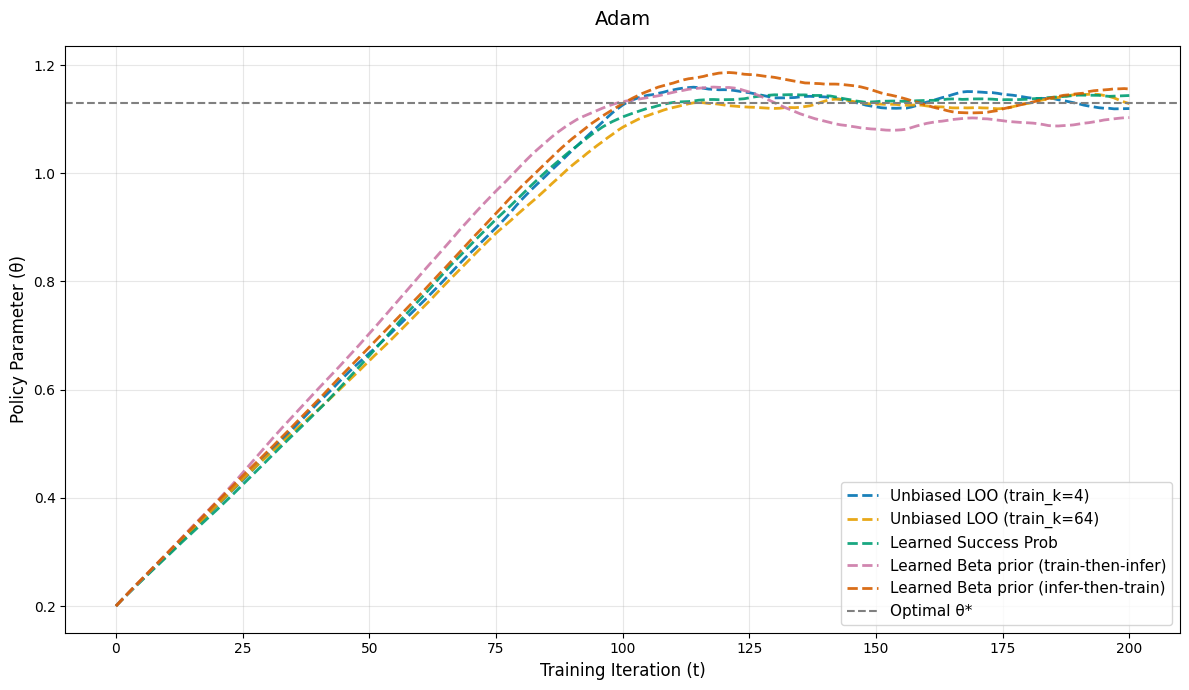

In [39]:

# =====================================================================
# 3. PLOT THE LEARNING CURVES
# =====================================================================
# Okabe-Ito-style palette: colorblind-safe, spaced across hues (not the earlier `colors` from pass@k curves)
_line_colors = [
    "#0072B2",  # blue
    "#E69F00",  # orange
    "#009E73",  # bluish green
    "#CC79A7",  # red-purple
    "#D55E00",  # vermillion
    "#56B4E9",  # sky blue
    "#000000",  # black
    "#F0E442",  # yellow
    "#A65628",  # brown
]
plt.figure(figsize=(12, 7))

for idx, method in enumerate(thetas.keys()):
    plt.plot(trajectories[method], label=method, alpha=0.9, color=_line_colors[idx], linewidth=2, linestyle='--')

plt.title("Adam", fontsize=14, pad=15)
plt.xlabel("Training Iteration (t)", fontsize=12)
plt.ylabel("Policy Parameter (θ)", fontsize=12)
# plt.ylim(0.8, 1.5)
plt.axhline(k_to_best_theta[k], color='gray', linestyle='--', label='Optimal θ*')

plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [40]:
track_adv_var['Unbiased LOO (train_k=4)']

[0.0302734375,
 0.0302734375,
 0.0265960693359375,
 0.0265960693359375,
 0.015380859375,
 0.0191497802734375,
 0.0339202880859375,
 0.02288818359375,
 0.03753662109375,
 0.015380859375,
 0.0302734375,
 0.0339202880859375,
 0.0551605224609375,
 0.03753662109375,
 0.02288818359375,
 0.0302734375,
 0.0191497802734375,
 0.0265960693359375,
 0.0265960693359375,
 0.0302734375,
 0.0302734375,
 0.0339202880859375,
 0.0339202880859375,
 0.0339202880859375,
 0.02288818359375,
 0.03753662109375,
 0.0482025146484375,
 0.0482025146484375,
 0.0191497802734375,
 0.0339202880859375,
 0.0339202880859375,
 0.0265960693359375,
 0.0265960693359375,
 0.0339202880859375,
 0.044677734375,
 0.0265960693359375,
 0.015380859375,
 0.0302734375,
 0.0265960693359375,
 0.0115814208984375,
 0.0302734375,
 0.0191497802734375,
 0.0302734375,
 0.0411224365234375,
 0.015380859375,
 0.0302734375,
 0.0265960693359375,
 0.0265960693359375,
 0.03753662109375,
 0.044677734375,
 0.02288818359375,
 0.03753662109375,
 0.0411224

In [41]:
# =====================================================================
# 5. VISUALIZE AND PRINT INTERNAL METRICS
# =====================================================================
METRIC_SMOOTH_WINDOW = 25  # centered moving average; use 1 for raw trajectories

def _smooth_1d(y, window):
    y = np.asarray(y, dtype=float)
    w = int(window)
    if w <= 1 or len(y) < 3:
        return y
    if w % 2 == 0:
        w += 1
    pad = w // 2
    ypad = np.pad(y, (pad, pad), mode="edge")
    kernel = np.ones(w, dtype=float) / w
    return np.convolve(ypad, kernel, mode="valid")

fig = plt.figure()

# Plot 1: Advantage Variance
for m, vals in track_adv_var.items():
    axes.plot(_smooth_1d(vals, METRIC_SMOOTH_WINDOW), label=m, alpha=0.7)
axes.set_title("Advantage Variance (Gradient Noise)")
axes.set_yscale('log') # Log scale because CE variance explodes
axes.set_xlabel("Iteration")
axes.legend(fontsize=8)


plt.tight_layout()
plt.savefig('variance.png')
plt.show()

# Print Summary for LLM Context
print("\n" + "="*60)
print("METRICS SUMMARY (Average of final 100 iterations)")
print("="*60)

print("\n--- Advantage Variance ---")
for m, vals in track_adv_var.items():
    print(f"  {m}: {np.mean(vals[-100:]):.4f}")
    


<Figure size 640x480 with 0 Axes>


METRICS SUMMARY (Average of final 100 iterations)

--- Advantage Variance ---
  Unbiased LOO (train_k=4): 0.0709
  Unbiased LOO (train_k=64): 0.0706
  Learned Success Prob: 0.0180
  Learned Beta prior (train-then-infer): 0.0121
  Learned Beta prior (infer-then-train): 0.0219
